    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
(400, 5)
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


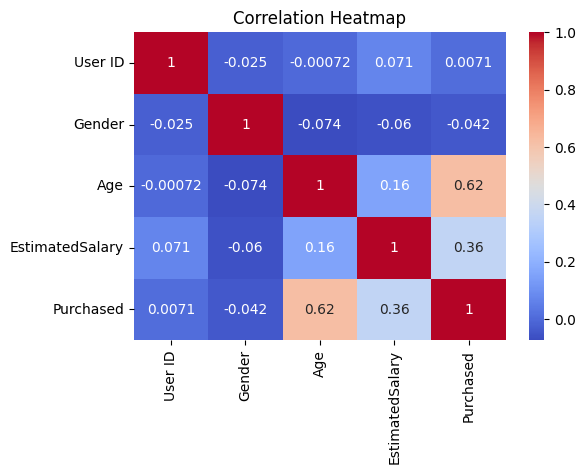

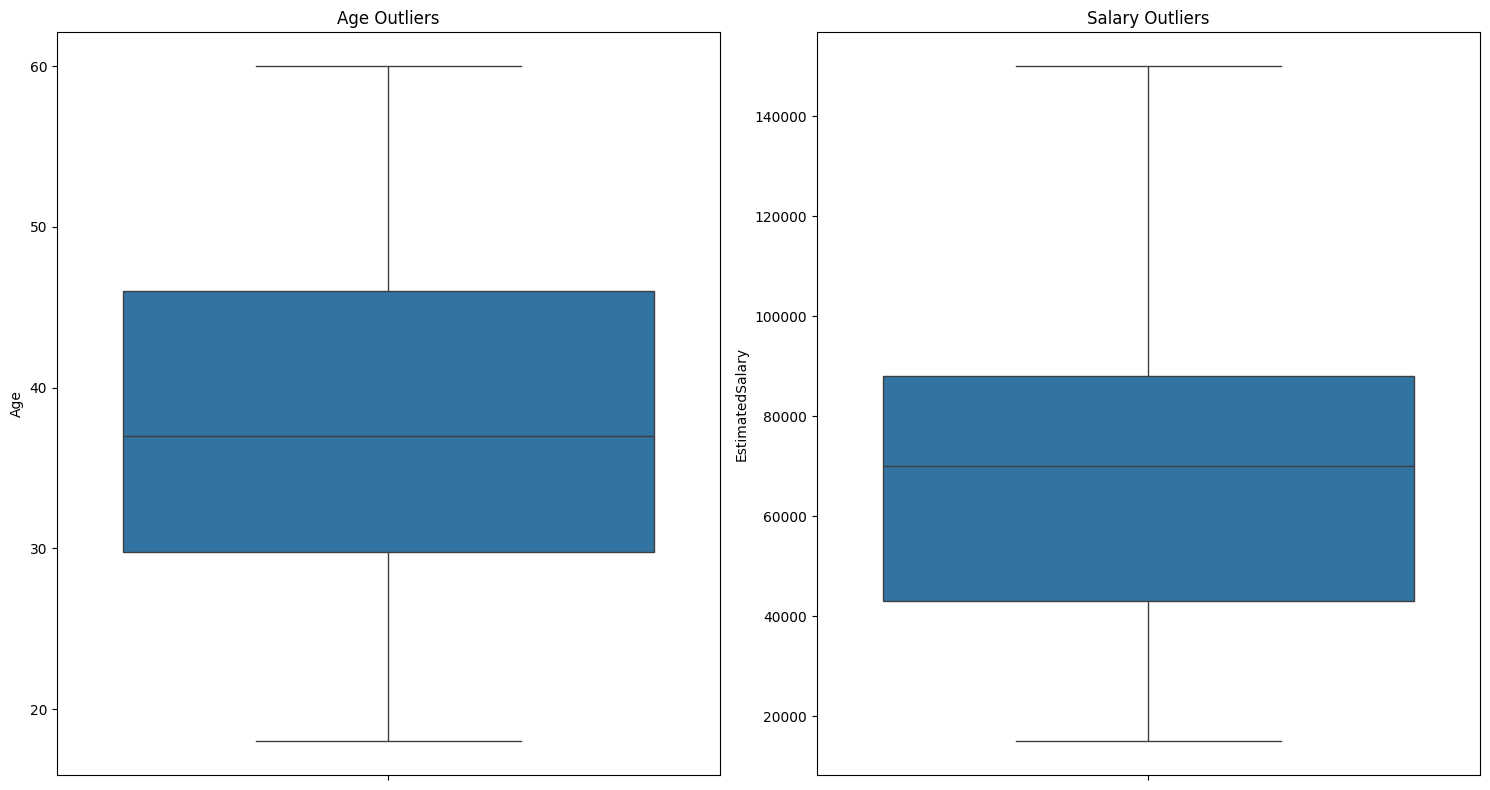

Confusion Matrix:
 [[65  3]
 [ 7 25]]
TP = 25
TN = 65
FP = 3
FN = 7
Accuracy = 0.9
Error Rate = 0.09999999999999998
Precision = 0.8928571428571429
Recall = 0.78125
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        68
           1       0.89      0.78      0.83        32

    accuracy                           0.90       100
   macro avg       0.90      0.87      0.88       100
weighted avg       0.90      0.90      0.90       100



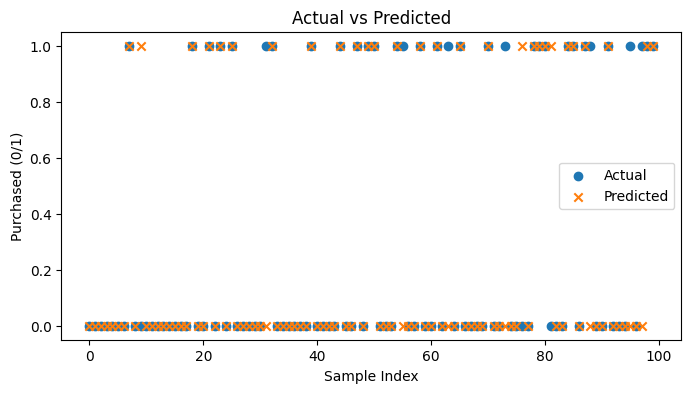

In [3]:
# Logistic Regression on Social_Network_Ads.csv
# Practical: Classification + Confusion Matrix Metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

# Load dataset
df = pd.read_csv("Social_Network_Ads.csv")

# -------------------------------
# Basic Info
# -------------------------------
print(df.head())
print(df.shape)
print(df.isnull().sum())

# -------------------------------
# Missing Values (fill with mean)
# -------------------------------
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["EstimatedSalary"] = df["EstimatedSalary"].fillna(df["EstimatedSalary"].mean())

# -------------------------------
# Encode Gender
# -------------------------------
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# -------------------------------
# Heatmap
# -------------------------------
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# Outlier Detection (Boxplot)
# -------------------------------
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
sns.boxplot(y=df["Age"])
plt.title("Age Outliers")

plt.subplot(1,2,2)
sns.boxplot(y=df["EstimatedSalary"])
plt.title("Salary Outliers")

plt.tight_layout()
plt.show()

# -------------------------------
# Features and Target
# -------------------------------
X = df[["Age", "EstimatedSalary", "Gender"]]
y = df["Purchased"]

# -------------------------------
# Train Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# -------------------------------
# Feature Scaling
# -------------------------------
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# -------------------------------
# Logistic Regression Model
# -------------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

# -------------------------------
# Metrics
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy =", accuracy)
print("Error Rate =", error_rate)
print("Precision =", precision)
print("Recall =", recall)

# -------------------------------
# Classification Report
# -------------------------------
print(classification_report(y_test, y_pred))

# -------------------------------
# Actual vs Predicted Scatter Plot
# -------------------------------
plt.figure(figsize=(8,4))
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, marker="x", label="Predicted")

plt.title("Actual vs Predicted")
plt.xlabel("Sample Index")
plt.ylabel("Purchased (0/1)")
plt.legend()
plt.show()